In [2]:
# 必要なライブラリのimport
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_theme()

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


H0:ラインによる濃度の差はない
H1:ラインによる濃度の差はある

In [4]:
data1 = pd.read_csv('ethanol_data.csv')

data1.head()

,Density,Line
0,71.624345,A
1,69.388244,A
2,69.471828,A
3,68.927031,A
4,70.865408,A


In [5]:
data1.tail()

,Density,Line
45,70.582481,E
46,68.090768,E
47,68.408363,E
48,69.187603,E
49,68.670130,E


<Axes: xlabel='Line', ylabel='Density'>

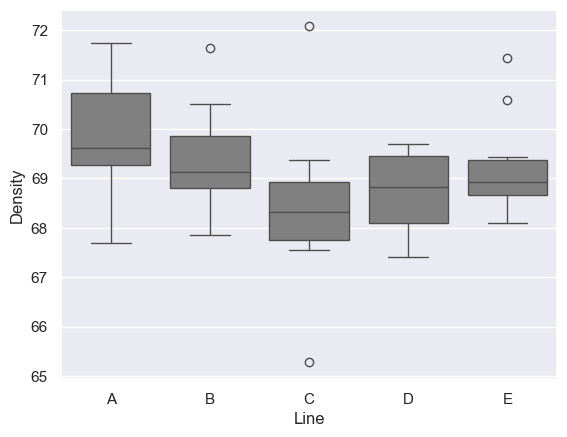

In [6]:
# 箱ひげ図を描画
sns.boxplot(x='Line', y='Density', data=data1, color = 'gray')

In [7]:
# 製造ラインごとの濃度の平均
me_Line_A = np.mean(data1.query('Line == "A"')['Density'])
me_Line_B = np.mean(data1.query('Line == "B"')['Density'])
me_Line_C = np.mean(data1.query('Line == "C"')['Density'])
me_Line_D = np.mean(data1.query('Line == "D"')['Density'])
me_Line_E = np.mean(data1.query('Line == "E"')['Density'])

print('Feed A:', me_Line_A)
print('Feed B:', me_Line_B)
print('Feed C:', me_Line_C)
print('Feed D:', me_Line_D)
print('Feed E:', me_Line_E)

Feed A: 69.9028591091939
Feed B: 69.36865005840154
Feed C: 68.42904350984494
Feed D: 68.73809656689362
Feed E: 69.23379915563066


In [8]:
count_Line_A = len(data1.query('Line == "A"')['Density'])
count_Line_B = len(data1.query('Line == "B"')['Density'])
count_Line_C = len(data1.query('Line == "C"')['Density'])
count_Line_D = len(data1.query('Line == "D"')['Density'])
count_Line_E = len(data1.query('Line == "E"')['Density'])

print('Line A count:', count_Line_A)
print('Line B count:', count_Line_B)
print('Line C count:', count_Line_C)
print('Line D count:', count_Line_D)
print('Line E count:', count_Line_E)

Line A count: 10
Line B count: 10
Line C count: 10
Line D count: 10
Line E count: 10


In [9]:
# データ全体の体長の平均
mu_all = np.mean(data1['Density'])
mu_all

69.13448967999292

In [11]:
# 各群の平均の配列
# 3つの数字が30個ずつ並んだリストを作成し、ndarrayに変換
mu_n_list = [me_Line_A]*data1.query('Line == "A"').shape[0] + \
			[me_Line_B]*data1.query('Line == "B"').shape[0] + \
			[me_Line_C]*data1.query('Line == "C"').shape[0] + \
			[me_Line_D]*data1.query('Line == "D"').shape[0] + \
			[me_Line_E]*data1.query('Line == "E"').shape[0]
mu_n = np.array(mu_n_list)

#print(mu_n)

# 効果（各群平均 のデータ全体の平均からのずれ）
effect = mu_n - mu_all
#print(effect)

# 効果の平方和（群間平方和）
squares_feed = np.sum(effect**2)
squares_feed

13.098668335875512

In [12]:
# 誤差（その他のずれ）
resid = data1['Density'] - mu_n
#print(resid)

# 誤差の平方和（群内平方和）
squares_resid = np.sum(resid**2)
squares_resid

67.4069531127806

In [17]:
# 群間変動（効果）の自由度 = 3(飼料の数) - 1
df_line = 5 - 1

# 群内変動（誤差）の自由度 = 飼料Aの自由度 + 飼料Bの自由度 + 飼料Cの自由度
#                      = (30 - 1) + (30 - 1) + (30 - 1)
df_resid = (10 - 1) + (10 - 1) + (10 - 1) + (10 - 1) + (10 - 1) 

print("df_line: ",df_line)
print("df_resid: ",df_resid)

df_line:  4
df_resid:  45


In [18]:
# 効果の分散
variance_line = squares_feed/df_line
variance_line

3.274667083968878

In [19]:
# 誤差の分散
variance_resid = squares_resid/df_resid
variance_resid

1.4979322913951245

In [20]:
# F比を計算
f_ratio = variance_line/variance_resid
f_ratio

2.1861249021602718

In [21]:
# p値を計算
1-sp.stats.f.cdf(x=f_ratio, dfn=df_line, dfd=df_resid)

0.08574964851206646

p値が有意水準の0.05を上回っているので、有意差がない、つまり「ラインによって濃度の差はない」と判断できる。（帰無仮説を棄却しない）

In [22]:
# statsmodelsで一元分散分析を実施
anova_model_1 = smf.ols('Density ~ Line', data=data1).fit()
sm.stats.anova_lm(anova_model_1, typ=2)

,sum_sq,df,F,PR(>F)
Line,13.098668,4.0,2.186125,0.08575
Residual,67.406953,45.0,NaN,NaN
